In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
%matplotlib inline

In [2]:
import os
import sys
current_dir = os.getcwd()  
source_dir  = os.path.join(current_dir, "source")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

In [3]:
import numpy as np
from bao import BAOCosmology,BAOLikelihood
from cosmoprimo import Cosmology
from cosmoprimo.fiducial import DESI,AbacusSummit
from desilike.likelihoods.supernovae import Union3SNLikelihood,PantheonPlusSNLikelihood,DESY5SNLikelihood
from desilike import setup_logging
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
setup_logging()

In [15]:
from compressed_sn import rebin_SN,CompressedPantheonPlusSNLikelihood
from utils import plot_sn_rebin_with_residual

# PantheonPlus

In [7]:
pp=PantheonPlusSNLikelihood(cosmo=DESI())

In [17]:
pp.calculate(0) ### MUST use nuisance parameters = 0

In [9]:
pp.loglikelihood

Array(-13316773.04901222, dtype=float64)

In [10]:
pp.covariance

array([[ 0.06543689, -0.00083541, -0.00124244, ..., -0.00077386,
        -0.00075876, -0.0006363 ],
       [-0.00083541,  0.06930601,  0.02413895, ...,  0.0002077 ,
         0.00156451,  0.00183639],
       [-0.00124244,  0.02413895,  0.0592691 , ...,  0.00091788,
         0.00204978,  0.00249542],
       ...,
       [-0.00077386,  0.0002077 ,  0.00091788, ...,  0.04157373,
         0.00490226,  0.00588703],
       [-0.00075876,  0.00156451,  0.00204978, ...,  0.00490226,
         0.06742823,  0.00875111],
       [-0.0006363 ,  0.00183639,  0.00249542, ...,  0.00588703,
         0.00875111,  0.04499005]])

In [11]:
pp.light_curve_params

{'CID': array(['2013E', '1999ac', '1999ac', ..., 'stone', 'wilson', 'colfax'],
       dtype='<U32'),
 'IDSURVEY': array([ 56.,  57.,  62., ..., 106., 106., 106.]),
 'zHD': array([0.01016, 0.01017, 0.01017, ..., 1.80119, 1.91165, 2.26137]),
 'zHDERR': array([0.00085, 0.00084, 0.00084, ..., 0.02014, 0.00263, 0.02018]),
 'zCMB': array([0.01042, 0.00979, 0.00979, ..., 1.80111, 1.9116 , 2.2613 ]),
 'zCMBERR': array([8.e-05, 2.e-05, 2.e-05, ..., 2.e-02, 1.e-03, 2.e-02]),
 'zHEL': array([0.00936, 0.00947, 0.00947, ..., 1.8    , 1.91401, 2.26   ]),
 'zHELERR': array([8.e-05, 2.e-05, 2.e-05, ..., 2.e-02, 1.e-03, 2.e-02]),
 'm_b_corr': array([13.5264, 13.6652, 13.7144, ..., 26.2335, 26.1703, 26.9298]),
 'm_b_corr_err_DIAG': array([0.3475  , 0.364224, 0.34081 , ..., 0.280685, 0.357624, 0.280011]),
 'MU_SH0ES': array([32.7794, 32.9182, 32.9674, ..., 45.4865, 45.4233, 46.1828]),
 'MU_SH0ES_ERR_DIAG': array([0.348547, 0.365223, 0.341878, ..., 0.281981, 0.358642, 0.281309]),
 'CEPH_DIST': array([-9.,

In [12]:
pp.flatdata

array([13.52812039, 13.66670525, 13.71590525, ..., 26.23442268,
       26.16854065, 26.93071236])

In [16]:
bins = np.array([0.01, 0.125, 0.235, 0.325, 0.425, 0.625, 0.825, 3])

In [18]:
z_b, mu_b, err_b, cov_b, W = rebin_SN(pp.light_curve_params['zHD'],
                                      pp.flatdata,
                                      pp.covariance,
                                      bins,
                                      return_W=True,
                                     )

np.savez("compressed_sn_data/pantheonplus_compressed.npz",
         W=W,
         z_full=pp.light_curve_params['zHD'],
         flatdata_binned0=mu_b,      # this is "flatdata" compressed with Mb=0
         cov_binned=cov_b,
         ones_binned=W @ np.ones_like(pp.light_curve_params['zHD']))

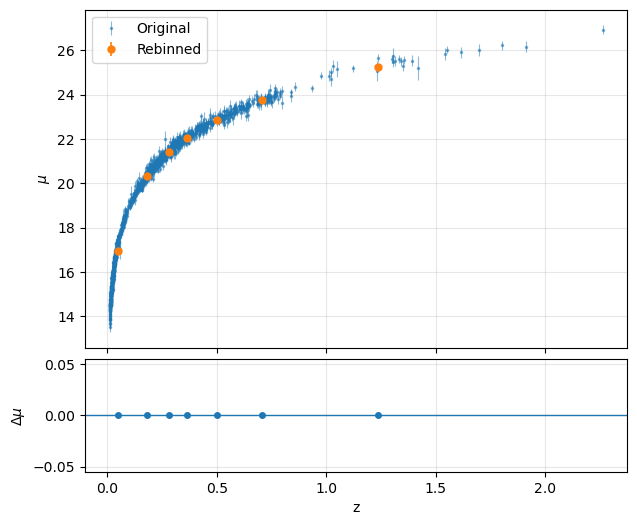

(<Figure size 700x600 with 2 Axes>,
 (<Axes: ylabel='$\\mu$'>, <Axes: xlabel='z', ylabel='$\\Delta\\mu$'>))

In [20]:
plot_sn_rebin_with_residual(pp.light_curve_params['zHD'],pp.flatdata,pp.covariance,
              z_b, mu_b,cov_b,W         
             )

## UNION3

In [25]:
un=Union3SNLikelihood(cosmo=DESI())

In [27]:
un.calculate(0)

In [28]:
un.flatdata

array([36.630361, 38.235499, 39.147691, 39.83488 , 40.340319, 40.813875,
       41.202487, 41.568946, 41.82265 , 42.136311, 42.352181, 42.599505,
       42.793121, 42.945322, 43.125351, 43.319655, 43.647594, 44.011256,
       44.191092, 44.577985, 44.842358, 45.997159])

In [39]:
un.light_curve_params

{'name': array(['bin00', 'bin01', 'bin02', 'bin03', 'bin04', 'bin05', 'bin06',
        'bin07', 'bin08', 'bin09', 'bin10', 'bin11', 'bin12', 'bin13',
        'bin14', 'bin15', 'bin16', 'bin17', 'bin18', 'bin19', 'bin20',
        'bin21'], dtype='<U5'),
 'zcmb': array([0.05    , 0.1     , 0.15    , 0.2     , 0.25    , 0.3     ,
        0.35    , 0.4     , 0.45    , 0.5     , 0.55    , 0.6     ,
        0.65    , 0.7     , 0.75    , 0.8     , 0.898138, 0.996276,
        1.094415, 1.232244, 1.390961, 2.26226 ]),
 'zhel': array([0.05    , 0.1     , 0.15    , 0.2     , 0.25    , 0.3     ,
        0.35    , 0.4     , 0.45    , 0.5     , 0.55    , 0.6     ,
        0.65    , 0.7     , 0.75    , 0.8     , 0.898138, 0.996276,
        1.094415, 1.232244, 1.390961, 2.26226 ]),
 'dz': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.]),
 'mb': array([36.630361, 38.235499, 39.147691, 39.83488 , 40.340319, 40.813875,
        41.202487, 41.568946, 4

In [32]:
z_b, mu_b, err_b, cov_b, W = rebin_SN(un.light_curve_params['zcmb'],
                                      un.flatdata,
                                      un.covariance,
                                      bins,
                                      return_W=True,
                                     )

np.savez("compressed_sn_data/union3_compressed.npz",
         W=W,
         z_full=un.light_curve_params['zcmb'],
         flatdata_binned0=mu_b,      # this is "flatdata" compressed with Mb=0
         cov_binned=cov_b,
         ones_binned=W @ np.ones_like(un.light_curve_params['zcmb']))

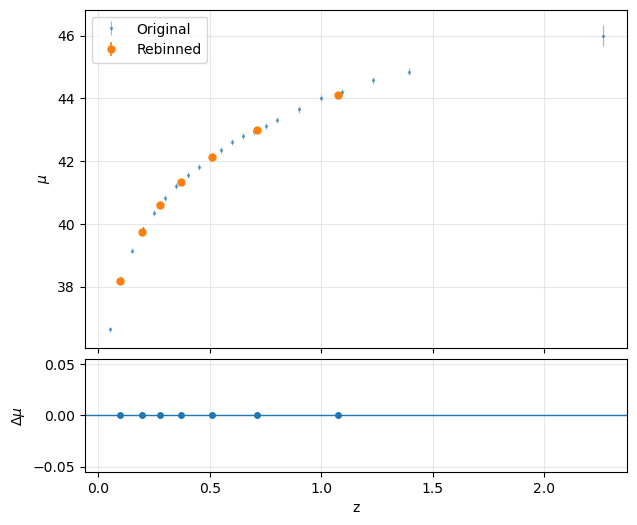

(<Figure size 700x600 with 2 Axes>,
 (<Axes: ylabel='$\\mu$'>, <Axes: xlabel='z', ylabel='$\\Delta\\mu$'>))

In [38]:
plot_sn_rebin_with_residual(un.light_curve_params['zcmb'],un.flatdata,un.covariance,
              z_b, mu_b,cov_b,W,show=True
             )

## DESY5

In [40]:
des=DESY5SNLikelihood(cosmo=DESI())

In [41]:
des.calculate(0)

[004252.83] [0/1] 02-01 21:32  DESY5SNLikelihood         INFO     Loading light-curve from /global/cfs/cdirs/desi/science/cpe//perlmutter/cosmodesiconda/20240118-1.0.0/desilike/data/DESY5SNLikelihood/DES-SN5YR_HD.csv
[004252.86] [0/1] 02-01 21:32  DESY5SNLikelihood         INFO     Loading covariance from /global/cfs/cdirs/desi/science/cpe//perlmutter/cosmodesiconda/20240118-1.0.0/desilike/data/DESY5SNLikelihood/STAT+SYS.txt


In [45]:
des.flatdata.shape

(1829,)

In [43]:
des.flattheory

Array([40.54038219, 41.31227578, 41.65024559, ..., 35.35753634,
       35.35156602, 38.22681425], dtype=float64)

In [47]:
des.light_curve_params

{'CID': array(['1246275.0', '1246281.0', '1246314.0', ..., 'SN2017mf', 'SN2017ms',
        'iPTF17dz'], dtype='<U32'),
 'IDSURVEY': array([ 10.,  10.,  10., ..., 150., 150., 150.]),
 'zCMB': array([0.24605, 0.33549, 0.38337, ..., 0.02618, 0.02538, 0.09284]),
 'zHD': array([0.24605, 0.33549, 0.38337, ..., 0.02598, 0.02591, 0.09293]),
 'zHEL': array([0.24651, 0.336  , 0.38388, ..., 0.02561, 0.02448, 0.092  ]),
 'MU': array([40.5938, 41.2263, 41.6383, ..., 35.3916, 35.3421, 38.343 ]),
 'MUERR_FINAL': array([0.0968, 0.136 , 0.2332, ..., 0.1237, 0.116 , 0.2873])}

In [48]:
z_b, mu_b, err_b, cov_b, W = rebin_SN(des.light_curve_params['zHD'],
                                      des.flatdata,
                                      des.covariance,
                                      bins,
                                      return_W=True,
                                     )

np.savez("compressed_sn_data/desy5_compressed.npz",
         W=W,
         z_full=des.light_curve_params['zHD'],
         flatdata_binned0=mu_b,      # this is "flatdata" compressed with Mb=0
         cov_binned=cov_b,
         ones_binned=W @ np.ones_like(des.light_curve_params['zHD']))

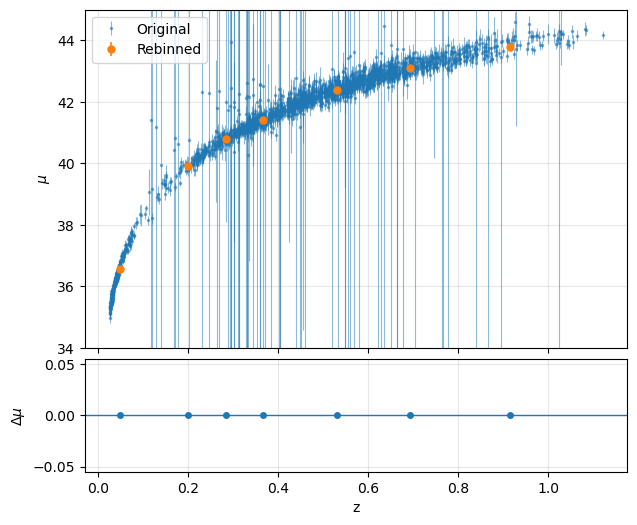

(<Figure size 700x600 with 2 Axes>,
 (<Axes: ylabel='$\\mu$'>, <Axes: xlabel='z', ylabel='$\\Delta\\mu$'>))

In [54]:
plot_sn_rebin_with_residual(des.light_curve_params['zHD'],des.flatdata,des.covariance,
              z_b, mu_b,cov_b,W,show=True, lim_y=(34,45)
             )

In [52]:
np.sqrt(np.diag(des.covariance))[np.sqrt(np.diag(des.covariance))>1]

array([280.15360385, 192.59200311, 161.75071483,   3.26155505,
       170.59731033, 257.72070618, 224.76070494, 185.23551483,
        15.46829086, 172.27551367, 172.63721479,   5.33021702,
         2.3196395 , 331.7325214 ,   1.19890201, 177.01681024,
       219.92541581,   1.1553239 , 188.50752657, 239.41490452,
       221.23971937, 137.17000757,  28.99266479,   2.92899135,
       209.20920416, 234.96242054, 252.58680158, 314.7000044 ,
        53.11598542,   1.07277389,   2.30184493, 266.67610321,
         4.80512263, 205.25190156, 232.06440828, 200.59700096,
       149.87456246, 241.05192571, 193.67430933, 226.70033866,
       238.5706005 , 186.90781475, 293.0621089 ,   8.39901449,
        17.30142324, 191.55572236,  90.33135472, 226.86079402,
       269.02130586, 252.28600529, 155.89610118, 202.29870144,
       209.94171683, 168.13521089, 204.13580455, 300.0360418 ,
         8.13636997, 142.27506478, 259.71600953, 200.13823386,
       175.33650856, 293.22890561,   3.04273605, 288.98

## Check samples

In [106]:
s1, w1, npar1 = load_chain('_out/original.txt')
s2, w2, npar2 = load_chain('_out/compressed.txt')

In [107]:
names, labels = default_names_labels('lcdm', npar1)

In [108]:
mc1 = make_mcsamples(s1, w1, names, labels, 'original')
mc2 = make_mcsamples(s2, w2, names, labels, 'compressed')

Removed no burn in
Removed no burn in


In [111]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [mc1, mc2],
    params=names,
    filled=False,
    legend_labels=['original', 'compressed'],
)
g.export('_out/compare.png')